<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/USLargeCaps_Entry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta
!pip install scipy==1.16.2
!pip install hurst -q

## Install libraries

In [22]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
from datetime import datetime
import time
import ta
import random
import requests
from datetime import datetime, timedelta
from scipy.stats import linregress
from transformers import pipeline
import matplotlib.pyplot as plt
from hurst import compute_Hc

from dataclasses import dataclass, field
from typing import Optional
import warnings
warnings.filterwarnings("ignore")
# ensure reproducibility
random.seed(42)
print("Libraries Installed!")

1.4.0
Libraries Installed!


## What is the market doing?

Calculating rolling Hurst...
Progress: 500/501 | Valid: 321
Finished! Valid Hurst values: 321/321

Last 10 Days - Hurst, Alpha, Regime & Adaptive EMAs
             Hurst   Alpha                        Regime  Fast_EMA_Len  \
2026-05-11  0.5473  0.9054     Random Walk — Reduce Size             5   
2026-05-12  0.5352  0.9296     Random Walk — Reduce Size             5   
2026-05-13  0.5385  0.9230     Random Walk — Reduce Size             5   
2026-05-14  0.5622  0.8757  Trending — Momentum Favoured             5   
2026-05-15  0.5688  0.8624  Trending — Momentum Favoured             5   
2026-05-18  0.5727  0.8546  Trending — Momentum Favoured             5   
2026-05-19  0.5779  0.8441  Trending — Momentum Favoured             5   
2026-05-20  0.5947  0.8105  Trending — Momentum Favoured             6   
2026-05-21  0.5900  0.8201  Trending — Momentum Favoured             5   
2026-05-22  0.5854  0.8293  Trending — Momentum Favoured             5   

            Slow_EMA_Len  
2026-05

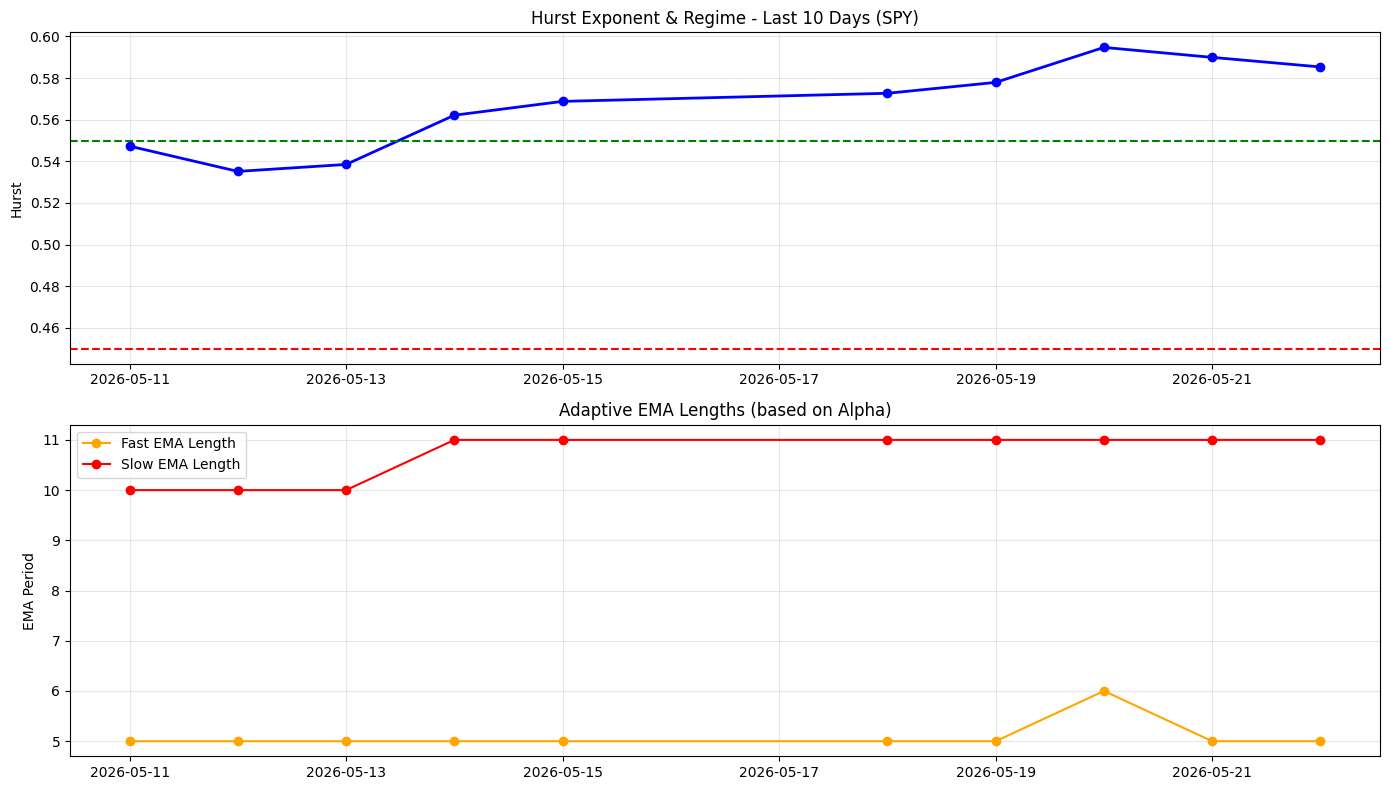

In [26]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from hurst import compute_Hc

def get_prices(ticker="SPY", period="2y"):
    df = yf.download(ticker, period=period, progress=False, auto_adjust=True)
    return df["Close"].dropna()

def hurst_exponent(ts):
    ts = np.asarray(ts, dtype=float)
    if len(ts) < 100:
        return np.nan
    try:
        H, _, _ = compute_Hc(ts, kind="price", simplified=True)
        return H
    except:
        return np.nan

def get_regime(h):
    if np.isnan(h):
        return "Unknown"
    elif h > 0.55:
        return "Trending — Momentum Favoured"
    elif h < 0.45:
        return "Mean Reverting — Counter-trend Favoured"
    else:
        return "Random Walk — Reduce Size"

# ====================== NEW FUNCTIONS ======================
def ema_length(alpha, n_min, n_max, k=2):
    """Convert market memory alpha into EMA length"""
    return n_min + (n_max - n_min) * (1 - alpha) ** k

def adaptive_ema_lengths(alpha):
    """Returns fast and slow EMA lengths"""
    fast = ema_length(alpha, n_min=5, n_max=20, k=2)
    slow = ema_length(alpha, n_min=10, n_max=50, k=2)
    return int(round(fast)), int(round(slow))

# ====================== ROLLING HURST ======================
def rolling_hurst(prices, window=180):
    hurst_vals = []
    dates = []
    valid = 0

    print("Calculating rolling Hurst...")

    for i in range(window, len(prices)):
        chunk = prices.iloc[i-window:i].values
        h = hurst_exponent(chunk)
        hurst_vals.append(h)
        dates.append(prices.index[i])

        if not np.isnan(h):
            valid += 1

        if i % 100 == 0:
            print(f"Progress: {i}/{len(prices)} | Valid: {valid}", end="\r")

    H = pd.Series(hurst_vals, index=dates, name="Hurst")
    print(f"\nFinished! Valid Hurst values: {valid}/{len(H)}")
    return H


# ====================== RUN ======================

ticker = "SPY"
prices = get_prices(ticker)

H = rolling_hurst(prices, window=180)
alpha = np.clip(2 - 2 * H, 0, 1)

# Create main dataframe
df = pd.DataFrame({
    "Hurst": H,
    "Alpha": alpha,
    "Regime": H.apply(get_regime)
})

# Add Adaptive EMA Lengths
df['Fast_EMA_Len'], df['Slow_EMA_Len'] = zip(*df['Alpha'].apply(adaptive_ema_lengths))

# Calculate actual EMAs using adaptive lengths (using latest Alpha for simplicity)
latest_alpha = df['Alpha'].iloc[-1]
fast_len, slow_len = adaptive_ema_lengths(latest_alpha)

df['Fast_EMA'] = prices.ewm(span=fast_len, adjust=False).mean()
df['Slow_EMA'] = prices.ewm(span=slow_len, adjust=False).mean()

# Last 10 days
last10 = df.dropna().tail(10)

print("\n" + "="*100)
print("Last 10 Days - Hurst, Alpha, Regime & Adaptive EMAs")
print(last10[['Hurst', 'Alpha', 'Regime', 'Fast_EMA_Len', 'Slow_EMA_Len']].round(4))

print(f"\nCurrent Adaptive EMAs (based on latest Alpha):")
print(f"Fast EMA Length : {fast_len}")
print(f"Slow EMA Length : {slow_len}")

# Plot
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(last10.index, last10["Hurst"], marker='o', color='blue', linewidth=2)
plt.axhline(0.55, color='green', linestyle='--')
plt.axhline(0.45, color='red', linestyle='--')
plt.title(f"Hurst Exponent & Regime - Last 10 Days ({ticker})")
plt.ylabel("Hurst")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(last10.index, last10["Fast_EMA_Len"], marker='o', label='Fast EMA Length', color='orange')
plt.plot(last10.index, last10["Slow_EMA_Len"], marker='o', label='Slow EMA Length', color='red')
plt.title("Adaptive EMA Lengths (based on Alpha)")
plt.ylabel("EMA Period")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()